# **Setup and file locations**

In [1]:
import os, json
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, top_k_accuracy_score)

IMG_SIZE, BATCH_SIZE = 224, 32
OUT = "/kaggle/working"
os.makedirs(f"{OUT}/figures", exist_ok=True)
print("Imports OK, TF", tf.__version__)

Imports OK, TF 2.20.0


In [2]:
DATA_DIR = SPLIT_DIR = MODEL_DIR = None
for root, dirs, files in os.walk("/kaggle/input"):
    # don't go into class folders (e.g. Tomato___healthy) or the unused image versions
    dirs[:] = [d for d in dirs if "___" not in d and d not in ("grayscale", "segmented")]
    if os.path.basename(root) == "color" and DATA_DIR is None:
        DATA_DIR = root
    if "train_split.csv" in files:
        SPLIT_DIR = root
    if "mobilenetv2.keras" in files:
        MODEL_DIR = root

print("Images:", DATA_DIR)
print("Splits:", SPLIT_DIR)
print("Models:", MODEL_DIR)

Images: /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/plantvillage dataset/color
Splits: /kaggle/input/notebooks/cyrinegraf/01-data-exploration
Models: /kaggle/input/notebooks/cyrinegraf/02-model-training/models


# **Load the validation and test sets**

In [3]:
def load_split(name):
    d = pd.read_csv(f"{SPLIT_DIR}/{name}_split.csv")
    d["path"] = d.apply(lambda r: os.path.join(DATA_DIR, r["class"], os.path.basename(r["path"])), axis=1)
    return d.reset_index(drop=True)

val_df, test_df = load_split("val"), load_split("test")

with open(f"{MODEL_DIR}/class_names.json") as f:
    class_names = json.load(f)
class_to_idx = {c: i for i, c in enumerate(class_names)}
NUM_CLASSES = len(class_names)

def load_image(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    return tf.image.resize(img, (IMG_SIZE, IMG_SIZE))

def make_dataset(d):
    ds = tf.data.Dataset.from_tensor_slices(d["path"].values)
    return ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds, test_ds = make_dataset(val_df), make_dataset(test_df)
y_val = val_df["class"].map(class_to_idx).values
y_test = test_df["class"].map(class_to_idx).values
print(f"Val: {len(val_df)} | Test: {len(test_df)} | Classes: {NUM_CLASSES}")

Val: 8146 | Test: 8146 | Classes: 38


I0000 00:00:1791138831.594291      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791138831.597903      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


# **Evaluate the three models on the test set**

In [4]:
results, test_probs = [], {}
for name in ["custom_cnn", "mobilenetv2", "efficientnetb0"]:
    model = keras.models.load_model(f"{MODEL_DIR}/{name}.keras")
    p = model.predict(test_ds, verbose=0)
    test_probs[name] = p
    y_pred = p.argmax(axis=1)
    results.append({
        "model": name,
        "test_accuracy": round(accuracy_score(y_test, y_pred), 4),
        "macro_f1": round(f1_score(y_test, y_pred, average="macro"), 4),
        "weighted_f1": round(f1_score(y_test, y_pred, average="weighted"), 4),
        "top3_accuracy": round(top_k_accuracy_score(y_test, p, k=3, labels=np.arange(NUM_CLASSES)), 4),
    })
    print(results[-1])

test_results = pd.DataFrame(results)
test_results.to_csv(f"{OUT}/test_results.csv", index=False)
test_results

{'model': 'custom_cnn', 'test_accuracy': 0.8294, 'macro_f1': 0.802, 'weighted_f1': 0.8314, 'top3_accuracy': np.float64(0.9563)}
{'model': 'mobilenetv2', 'test_accuracy': 0.9648, 'macro_f1': 0.9576, 'weighted_f1': 0.9645, 'top3_accuracy': np.float64(0.9966)}
{'model': 'efficientnetb0', 'test_accuracy': 0.9767, 'macro_f1': 0.9696, 'weighted_f1': 0.9768, 'top3_accuracy': np.float64(0.9979)}


,model,test_accuracy,macro_f1,weighted_f1,top3_accuracy
0,custom_cnn,0.8294,0.8020,0.8314,0.9563
1,mobilenetv2,0.9648,0.9576,0.9645,0.9966
2,efficientnetb0,0.9767,0.9696,0.9768,0.9979


# **Choose the model and analyze it per class**

Chosen model (best macro F1): efficientnetb0


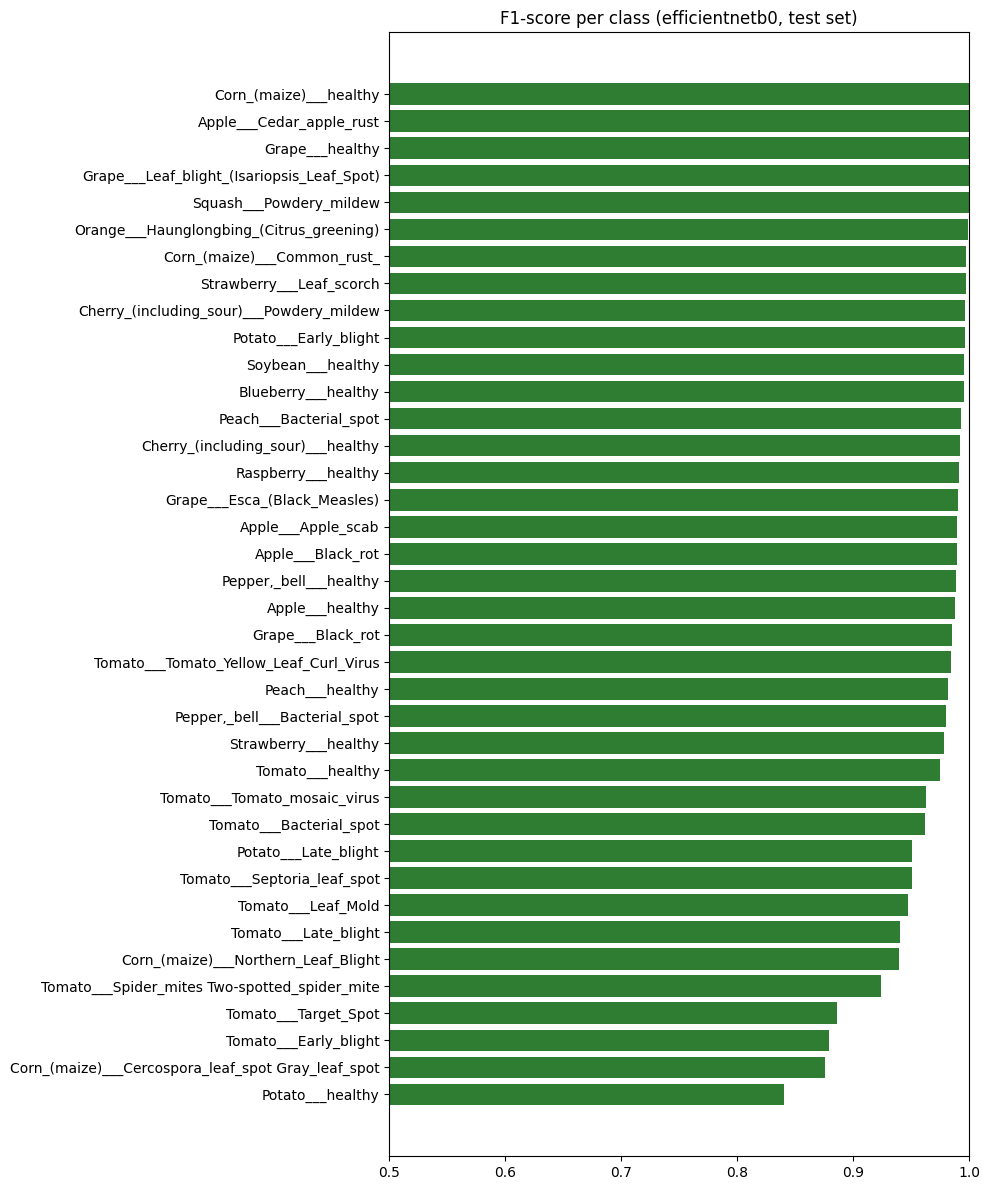

,precision,recall,f1-score,support
Potato___healthy,0.777778,0.913043,0.840000,23.0
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,0.881579,0.870130,0.875817,77.0
Tomato___Early_blight,0.939394,0.826667,0.879433,150.0
Tomato___Target_Spot,0.824490,0.957346,0.885965,211.0
Tomato___Spider_mites Two-spotted_spider_mite,0.908046,0.940476,0.923977,252.0


In [5]:
CHOSEN = test_results.sort_values("macro_f1", ascending=False).iloc[0]["model"]
print("Chosen model (best macro F1):", CHOSEN)

y_pred = test_probs[CHOSEN].argmax(axis=1)
report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report).T
report_df.to_csv(f"{OUT}/classification_report_{CHOSEN}.csv")

per_class = report_df.iloc[:NUM_CLASSES].sort_values("f1-score")
plt.figure(figsize=(10, 12))
plt.barh(per_class.index, per_class["f1-score"], color="#2E7D32")
plt.xlim(0.5, 1.0)
plt.title(f"F1-score per class ({CHOSEN}, test set)")
plt.tight_layout()
plt.savefig(f"{OUT}/figures/per_class_f1.png", dpi=150)
plt.show()
per_class.head(5)

# **Confusion matrix and most frequent confusions**

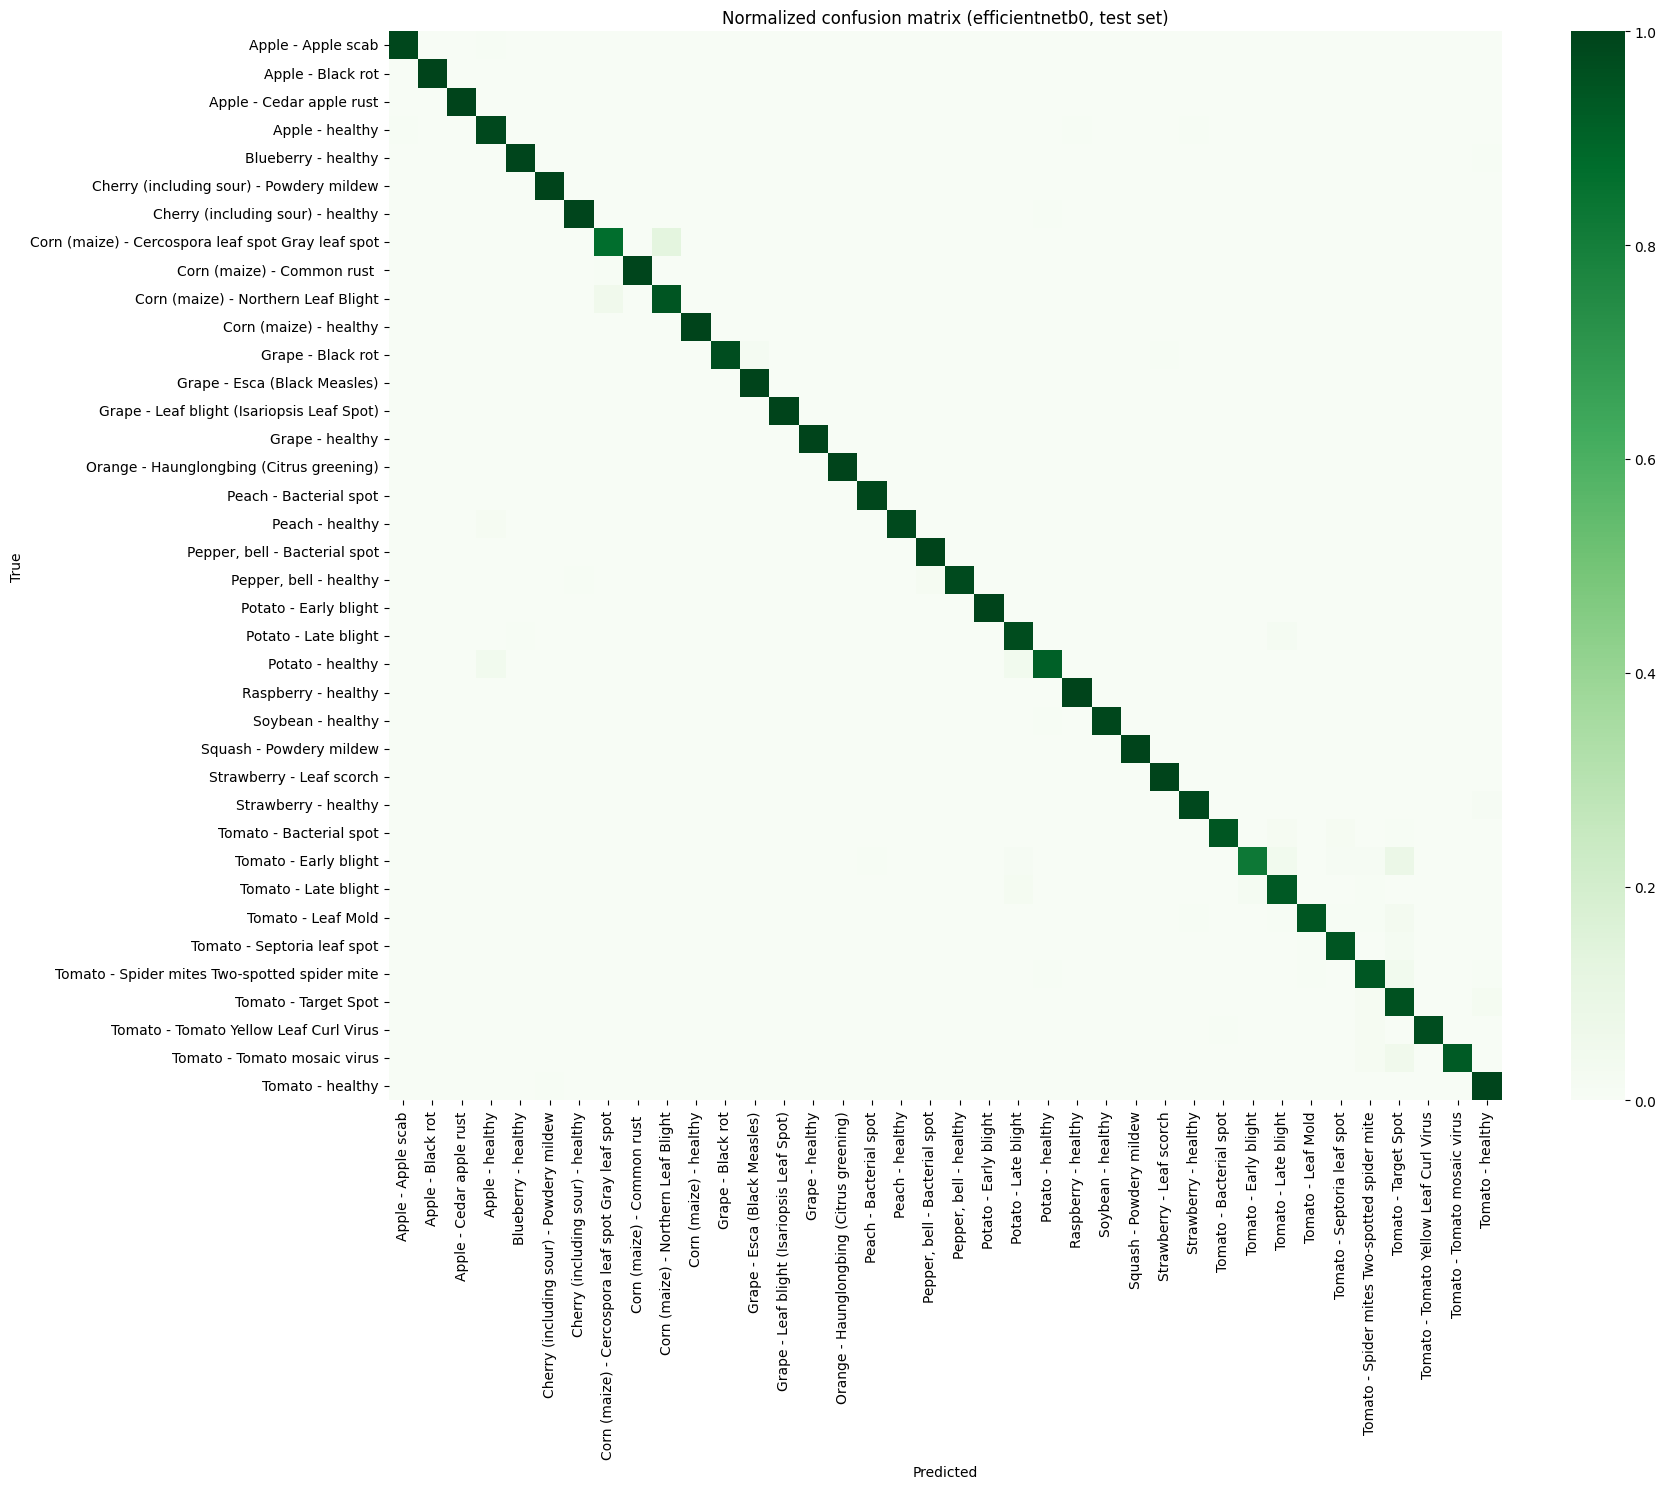

,true_class,predicted_as,count
0,Tomato___Tomato_Yellow_Leaf_Curl_Virus,Tomato___Spider_mites Two-spotted_spider_mite,14
1,Tomato___Early_blight,Tomato___Target_Spot,13
2,Tomato___Spider_mites Two-spotted_spider_mite,Tomato___Target_Spot,11
3,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,Corn_(maize)___Northern_Leaf_Blight,10
4,Corn_(maize)___Northern_Leaf_Blight,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,8
5,Tomato___Late_blight,Potato___Late_blight,7
6,Tomato___Bacterial_spot,Tomato___Septoria_leaf_spot,6
7,Tomato___Early_blight,Tomato___Late_blight,6
8,Tomato___Late_blight,Tomato___Early_blight,6
9,Tomato___Septoria_leaf_spot,Tomato___Target_Spot,6


In [6]:
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
short = [c.replace("___", " - ").replace("_", " ") for c in class_names]

plt.figure(figsize=(18, 15))
sns.heatmap(cm_norm, cmap="Greens", vmin=0, vmax=1, xticklabels=short, yticklabels=short)
plt.title(f"Normalized confusion matrix ({CHOSEN}, test set)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(f"{OUT}/figures/confusion_matrix.png", dpi=150)
plt.show()

pairs = [(class_names[i], class_names[j], int(cm[i, j]))
         for i in range(NUM_CLASSES) for j in range(NUM_CLASSES) if i != j and cm[i, j] > 0]
top_confusions = pd.DataFrame(sorted(pairs, key=lambda x: -x[2])[:10],
                              columns=["true_class", "predicted_as", "count"])
top_confusions.to_csv(f"{OUT}/top_confusions.csv", index=False)
top_confusions

**Look at some mistakes**

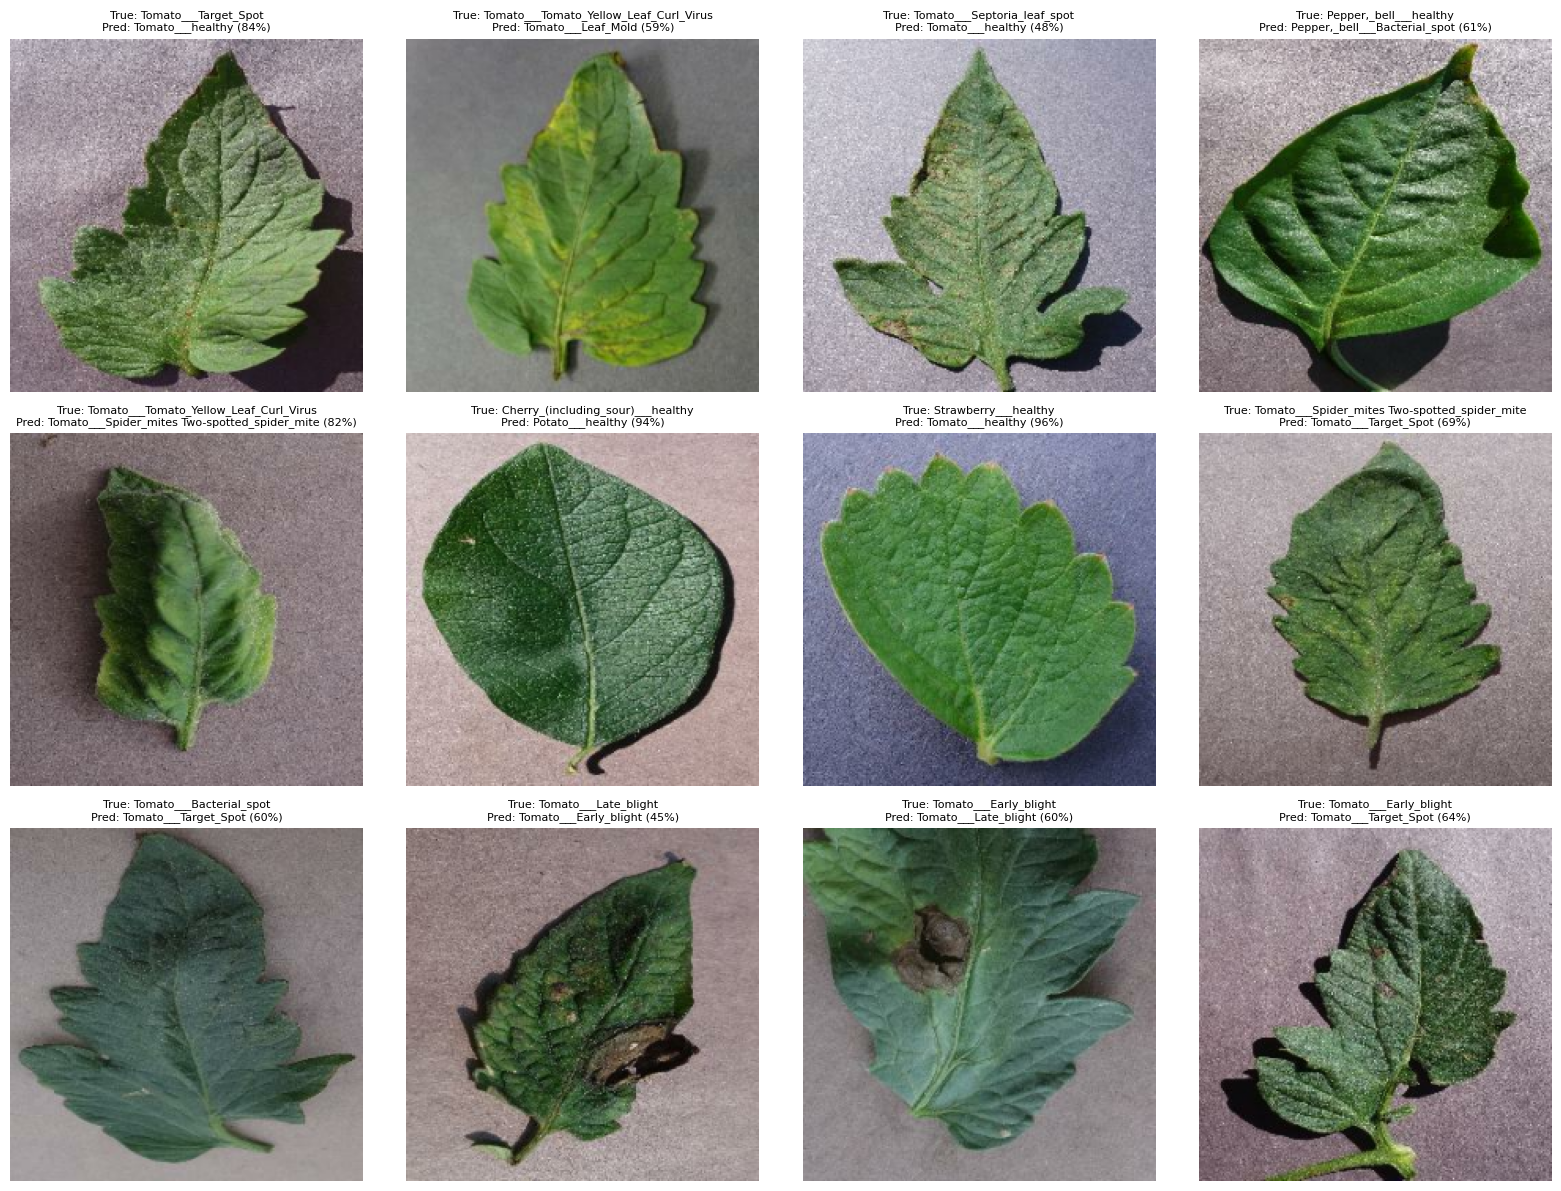

In [7]:
wrong = np.where(y_pred != y_test)[0]
sample = np.random.default_rng(42).choice(wrong, size=min(12, len(wrong)), replace=False)
conf = test_probs[CHOSEN].max(axis=1)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for ax, i in zip(axes.flat, sample):
    ax.imshow(load_image(test_df.loc[i, "path"]).numpy().astype("uint8"))
    ax.set_title(f"True: {class_names[y_test[i]]}\nPred: {class_names[y_pred[i]]} ({conf[i]:.0%})", fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.savefig(f"{OUT}/figures/misclassified_examples.png", dpi=120)
plt.show()

# **Choose the confidence threshold on the validation set**

Using model: efficientnetb0


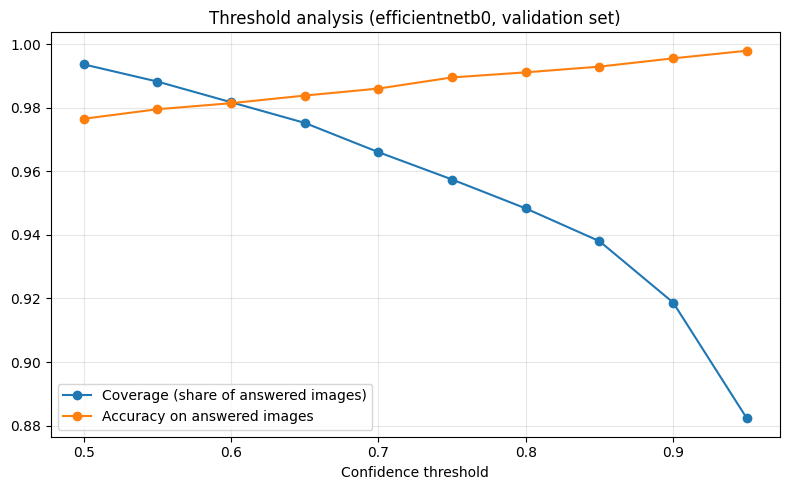

,threshold,coverage,accuracy_on_kept
0,0.50,0.9936,0.9765
1,0.55,0.9882,0.9795
2,0.60,0.9817,0.9814
3,0.65,0.9752,0.9838
4,0.70,0.9660,0.9860
5,0.75,0.9574,0.9895
6,0.80,0.9483,0.9911
7,0.85,0.9380,0.9929
8,0.90,0.9187,0.9955
9,0.95,0.8823,0.9979


In [8]:
if model.name != CHOSEN:
    print("Loading", CHOSEN, "... (can take 1-3 minutes)")
    model = keras.models.load_model(f"{MODEL_DIR}/{CHOSEN}.keras")
print("Using model:", model.name)
p_val = model.predict(val_ds, verbose=0)
val_conf = p_val.max(axis=1)
val_correct = p_val.argmax(axis=1) == y_val

rows = []
for t in np.arange(0.50, 0.96, 0.05):
    keep = val_conf >= t
    rows.append({"threshold": round(t, 2),
                 "coverage": round(keep.mean(), 4),
                 "accuracy_on_kept": round(val_correct[keep].mean(), 4)})
thr_df = pd.DataFrame(rows)
thr_df.to_csv(f"{OUT}/threshold_analysis.csv", index=False)

plt.figure(figsize=(8, 5))
plt.plot(thr_df["threshold"], thr_df["coverage"], marker="o", label="Coverage (share of answered images)")
plt.plot(thr_df["threshold"], thr_df["accuracy_on_kept"], marker="o", label="Accuracy on answered images")
plt.xlabel("Confidence threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.title(f"Threshold analysis ({CHOSEN}, validation set)")
plt.tight_layout()
plt.savefig(f"{OUT}/figures/threshold_analysis.png", dpi=150)
plt.show()
thr_df

In [9]:
THRESHOLD = 0.80  
keep = conf >= THRESHOLD
print(f"Test coverage: {keep.mean():.2%} | Test accuracy on kept: {(y_pred[keep] == y_test[keep]).mean():.2%}")

Test coverage: 94.97% | Test accuracy on kept: 99.35%


# **Grad-CAM**

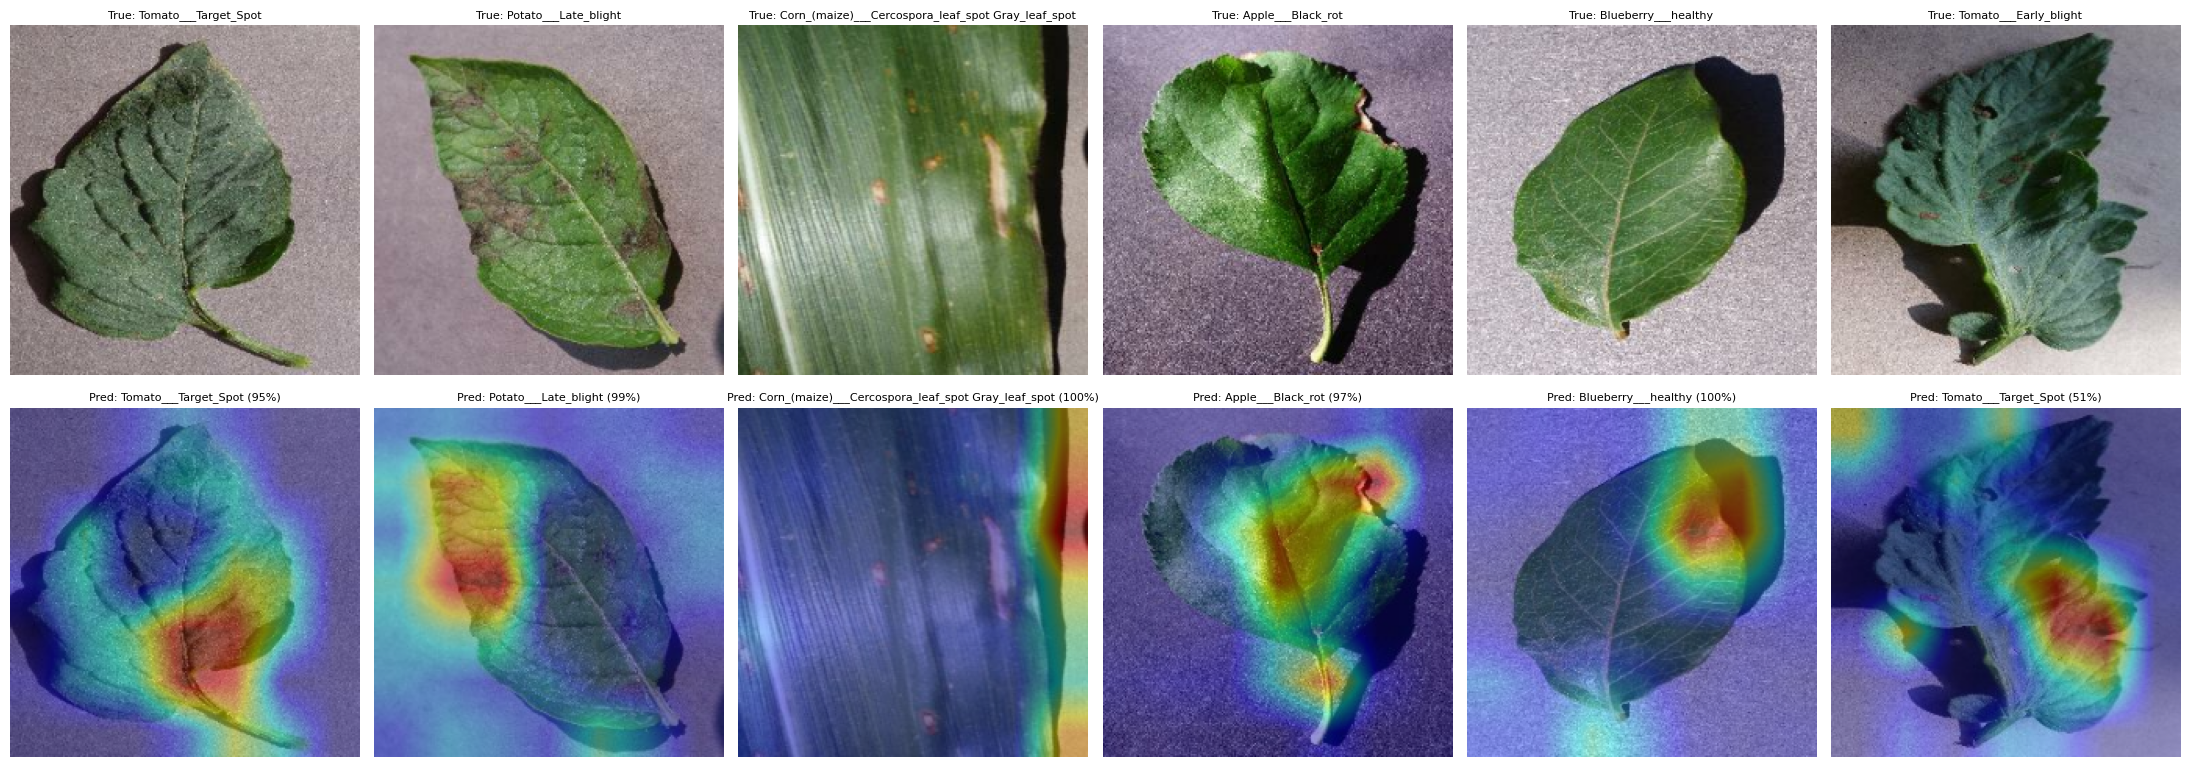

In [10]:
LAST_CONV = {"mobilenetv2": "out_relu", "efficientnetb0": "top_activation"}

def gradcam(model, img, last_conv):
    base = next(l for l in model.layers
                if isinstance(l, keras.Model) and any(s.name == last_conv for s in l.layers))
    base_multi = keras.Model(base.inputs, [base.get_layer(last_conv).output, base.output])
    layers_list = [l for l in model.layers if not isinstance(l, keras.layers.InputLayer)]
    idx = layers_list.index(base)
    with tf.GradientTape() as tape:
        x = tf.cast(img[None, ...], tf.float32)
        for layer in layers_list[:idx]:
            x = layer(x, training=False)
        conv_out, x = base_multi(x, training=False)
        tape.watch(conv_out)
        for layer in layers_list[idx + 1:]:
            x = layer(x, training=False)
        class_idx = int(tf.argmax(x[0]))
        score = x[:, class_idx]
    grads = tape.gradient(score, conv_out)
    weights = tf.reduce_mean(grads, axis=(1, 2))
    cam = tf.nn.relu(tf.reduce_sum(conv_out[0] * weights[0], axis=-1)).numpy()
    cam = cv2.resize(cam / (cam.max() + 1e-8), (IMG_SIZE, IMG_SIZE))
    return cam, class_idx, float(x[0, class_idx])

def overlay(img, cam):
    heat = cv2.cvtColor(cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    return np.uint8(0.6 * img + 0.4 * heat)

if CHOSEN in LAST_CONV:
    idxs = test_df.groupby("class").head(1).sample(6, random_state=1).index
    fig, axes = plt.subplots(2, 6, figsize=(22, 8))
    for col, i in enumerate(idxs):
        img = load_image(test_df.loc[i, "path"]).numpy()
        cam, c, p = gradcam(model, img, LAST_CONV[CHOSEN])
        axes[0, col].imshow(img.astype("uint8"))
        axes[0, col].set_title(f"True: {test_df.loc[i, 'class']}", fontsize=8)
        axes[1, col].imshow(overlay(img, cam))
        axes[1, col].set_title(f"Pred: {class_names[c]} ({p:.0%})", fontsize=8)
        axes[0, col].axis("off")
        axes[1, col].axis("off")
    plt.tight_layout()
    plt.savefig(f"{OUT}/figures/gradcam_examples.png", dpi=120)
    plt.show()